# Controller Log Analysis
Systematic diagnosis: perception → filter → gradients → saturation → orientation → timing.

In [ ]:
import pandas as pd

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

LOG_PATH = 'controller_log_20260319_180024.csv'  # <-- change if needed

df = pd.read_csv(LOG_PATH)

# Normalise det_valid to a proper boolean (stored as string 'True'/'False')
df['det_valid'] = df['det_valid'].astype(str).str.strip().str.lower() == 'true'

# Relative time axis in seconds
df['t_rel'] = df['time'] - df['time'].iloc[0]

print(f"Total rows     : {len(df)}")
print(f"Duration       : {df['t_rel'].iloc[-1]:.2f} s")
print(f"Valid detections: {df['det_valid'].sum()} / {len(df)} ({100*df['det_valid'].mean():.1f}%)")
df.head(3)

Total rows     : 3101
Duration       : 33.53 s
Valid detections: 2382 / 3101 (76.8%)


,time,det_valid,det_conf,det_t,det_u,det_v,det_w,det_h,det_area,det_theta,...,v_tcp_wx,v_tcp_wy,v_tcp_wz,vx,vy,vz,wx,wy,wz,t_rel
0,1.773914e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,1.773914e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.009140
2,1.773914e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.018928


## 1 · Detection Health
Is the perception pipeline reliable enough to drive a controller?

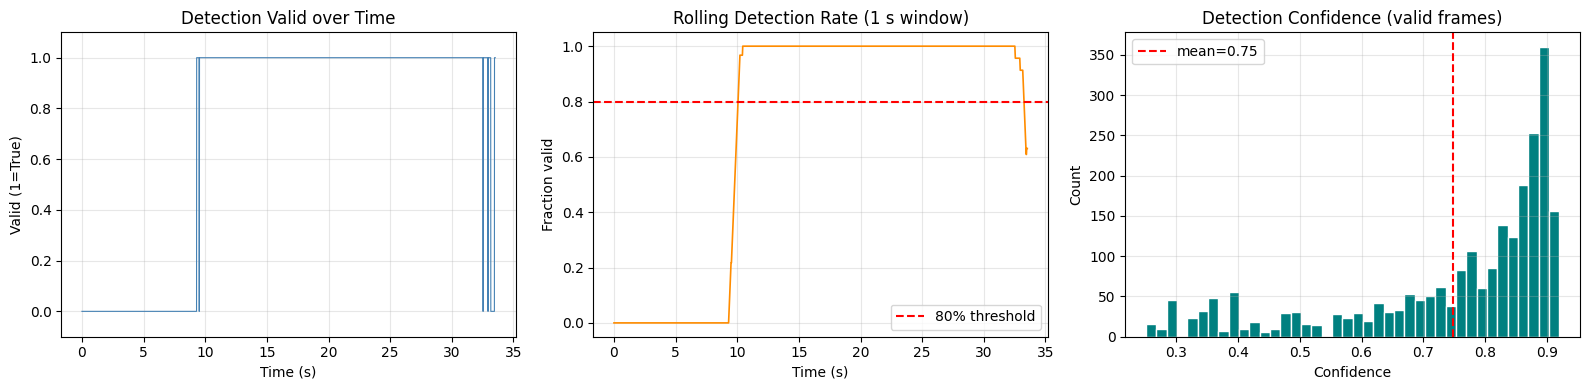


Dropout runs: 5
Longest dropout: 9.296 s
                 min        max  duration_s
det_valid                                  
1           0.000000   9.295792    9.295792
9          33.166255  33.456146    0.289891
5          32.525561  32.555937    0.030376
7          32.925842  32.955826    0.029984
3           9.506355   9.525890    0.019535


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- 1a: det_valid over time ---
axes[0].plot(df['t_rel'], df['det_valid'].astype(int), lw=0.8, color='steelblue')
axes[0].set_title('Detection Valid over Time')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Valid (1=True)')
axes[0].set_ylim(-0.1, 1.1)

# --- 1b: rolling validity rate (1-second window) ---
win = max(1, int(len(df) / df['t_rel'].iloc[-1]))  # approx samples-per-second
df['valid_rolling'] = df['det_valid'].astype(float).rolling(win, min_periods=1).mean()
axes[1].plot(df['t_rel'], df['valid_rolling'], color='darkorange', lw=1.2)
axes[1].axhline(0.8, ls='--', color='red', label='80% threshold')
axes[1].set_title('Rolling Detection Rate (1 s window)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Fraction valid')
axes[1].legend()

# --- 1c: confidence distribution (valid frames only) ---
valid = df[df['det_valid']]
if not valid.empty:
    axes[2].hist(valid['det_conf'].dropna(), bins=40, color='teal', edgecolor='white')
    axes[2].axvline(valid['det_conf'].mean(), color='red', ls='--', label=f"mean={valid['det_conf'].mean():.2f}")
    axes[2].set_title('Detection Confidence (valid frames)')
    axes[2].set_xlabel('Confidence'); axes[2].set_ylabel('Count')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'No valid detections', ha='center', va='center', fontsize=14, color='red',
                 transform=axes[2].transAxes)
    axes[2].set_title('Detection Confidence — NO DATA')

plt.tight_layout()
plt.savefig('1_detection_health.png', dpi=150)
plt.show()

# Summarise dropout runs
inv = (~df['det_valid']).astype(int)
runs = (inv != inv.shift()).cumsum()
dropout_lengths = df[~df['det_valid']].groupby(runs[~df['det_valid']])['t_rel'].agg(['min','max'])
dropout_lengths['duration_s'] = dropout_lengths['max'] - dropout_lengths['min']
print(f"\nDropout runs: {len(dropout_lengths)}")
print(f"Longest dropout: {dropout_lengths['duration_s'].max():.3f} s")
print(dropout_lengths.sort_values('duration_s', ascending=False).head(10).to_string())

## 2 · Detection Consistency
Are bbox and angle stable when the detector fires?

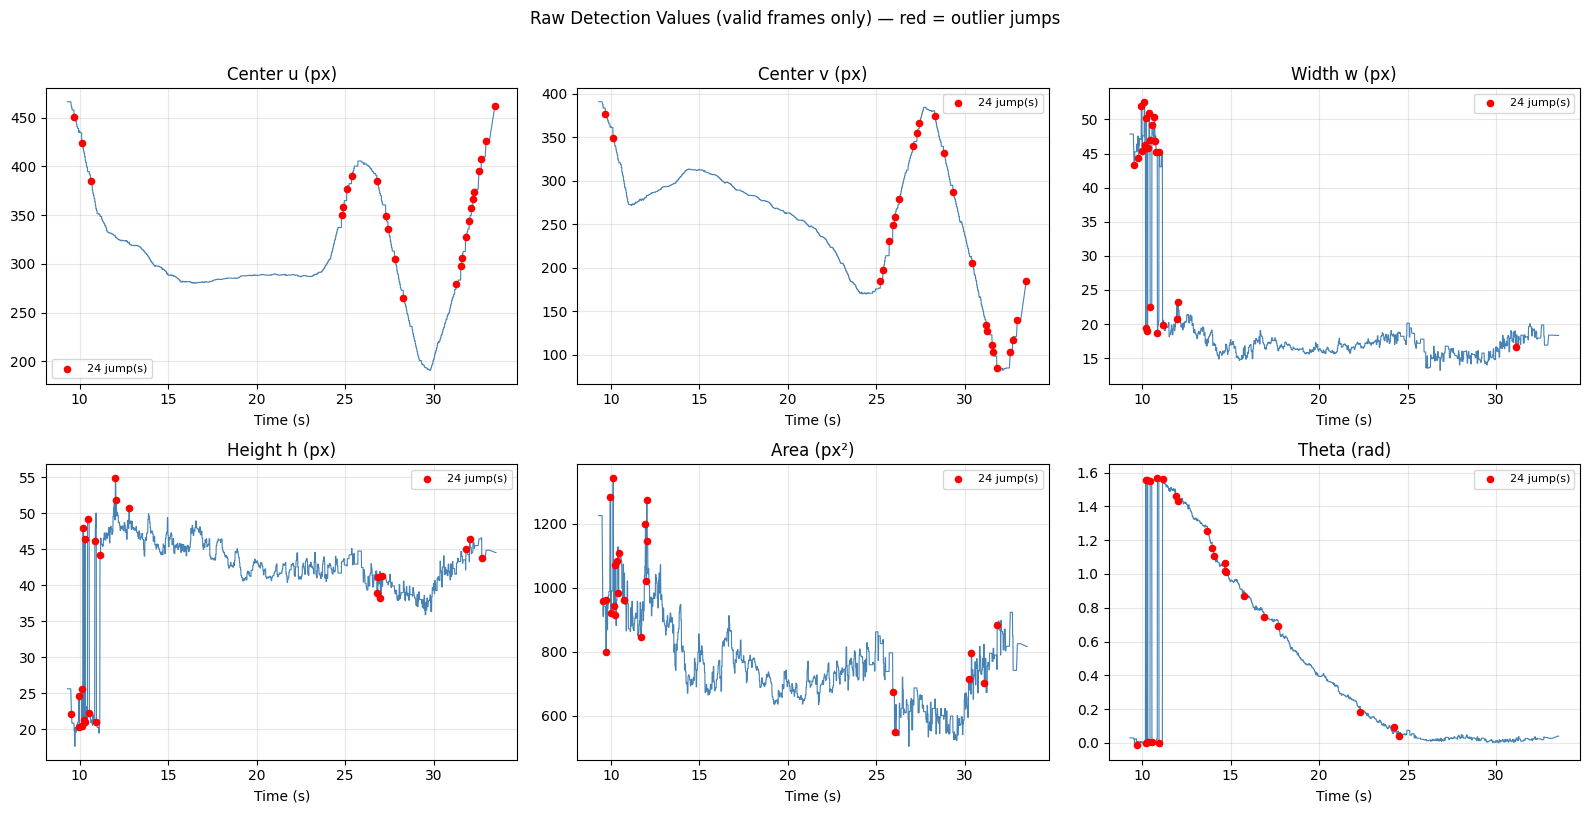

Theta flips (|Δθ| > 0.8π): 0


In [24]:
valid = df[df['det_valid']].copy()

if valid.empty:
    print("⚠️  No valid detections in log — skipping consistency checks.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for ax, col, label in zip(
        axes.flat,
        ['det_u', 'det_v', 'det_w', 'det_h', 'det_area', 'det_theta'],
        ['Center u (px)', 'Center v (px)', 'Width w (px)', 'Height h (px)', 'Area (px²)', 'Theta (rad)']
    ):
        ax.plot(valid['t_rel'], valid[col], lw=0.8, color='steelblue')
        # Frame-to-frame delta to spot jumps
        delta = valid[col].diff().abs()
        jumps = delta[delta > delta.quantile(0.99)]
        ax.scatter(valid.loc[jumps.index, 't_rel'], valid.loc[jumps.index, col],
                   color='red', s=20, zorder=5, label=f'{len(jumps)} jump(s)')
        ax.set_title(label); ax.set_xlabel('Time (s)')
        ax.legend(fontsize=8)

    plt.suptitle('Raw Detection Values (valid frames only) — red = outlier jumps', y=1.01)
    plt.tight_layout()
    plt.savefig('2_detection_consistency.png', dpi=150)
    plt.show()

    # Theta flip detection (ambiguity ±π)
    theta_delta = valid['det_theta'].diff().abs()
    flips = theta_delta[theta_delta > np.pi * 0.8]
    print(f"Theta flips (|Δθ| > 0.8π): {len(flips)}")
    if not flips.empty:
        print("  → Angle ambiguity detected. Unwrap or use atan2(sin, cos) in the filter.")

## 3 · Filter Audit
Is the low-pass filter lagging, too noisy, or diverging during dropouts?

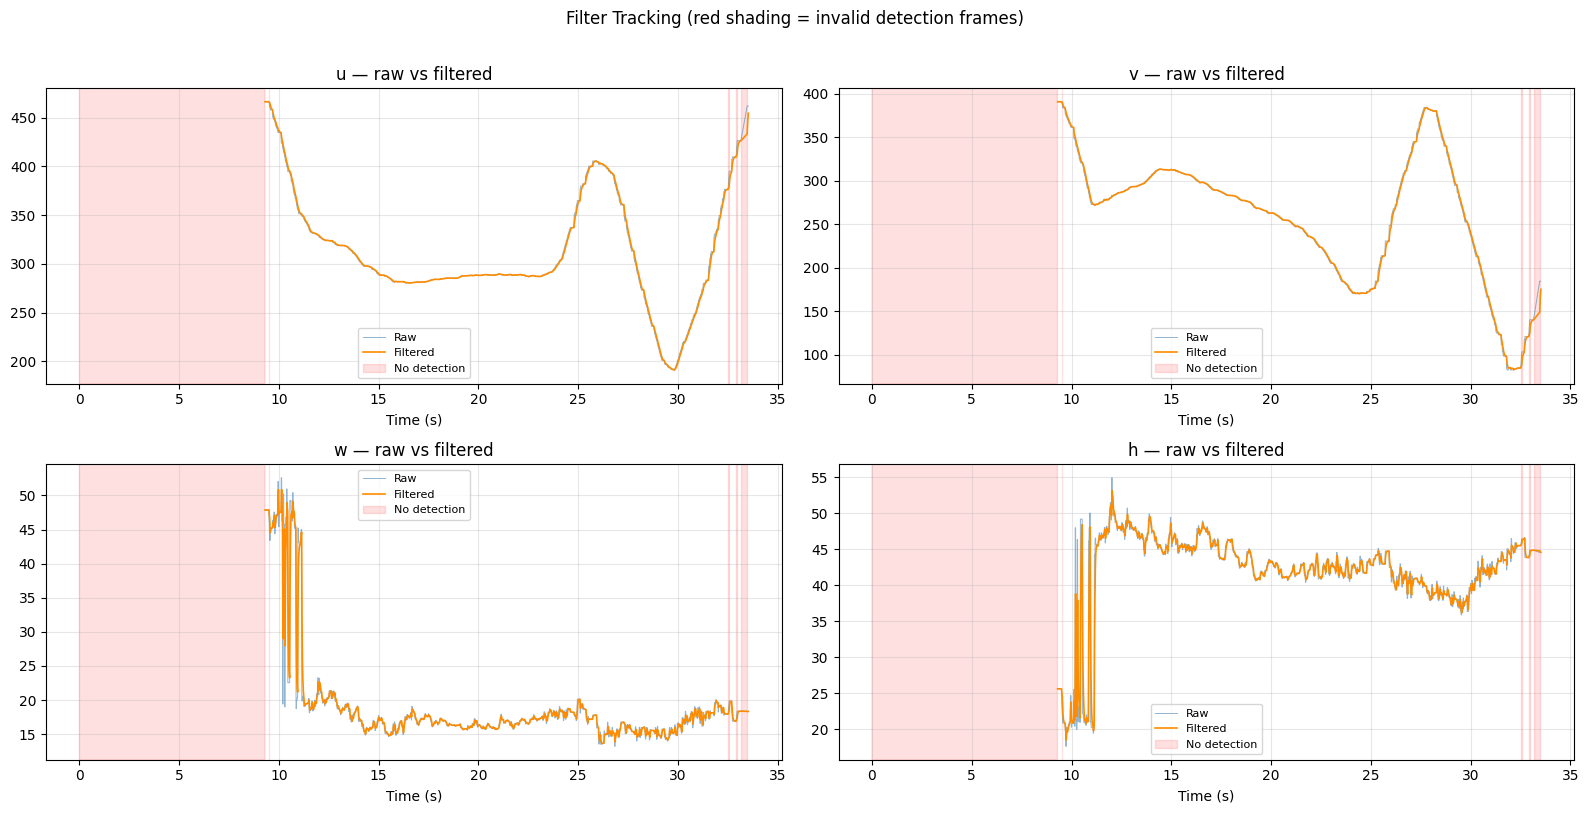

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

pairs = [
    ('det_u', 'u_f', 'u — raw vs filtered'),
    ('det_v', 'v_f', 'v — raw vs filtered'),
    ('det_w', 'w_f', 'w — raw vs filtered'),
    ('det_h', 'h_f', 'h — raw vs filtered'),
]

valid = df['det_valid']

for ax, (raw_col, filt_col, title) in zip(axes.flat, pairs):
    # --- plot data FIRST so axis limits are set from real values ---
    ax.plot(df.loc[valid, 't_rel'], df.loc[valid, raw_col],
            lw=0.7, alpha=0.6, label='Raw', color='steelblue')
    if filt_col and filt_col in df.columns:
        ax.plot(df.loc[valid, 't_rel'], df.loc[valid, filt_col],
                lw=1.2, label='Filtered', color='darkorange')

    # --- NOW shade invalid regions using the real y-limits ---
    ylo, yhi = ax.get_ylim()
    ax.fill_between(df['t_rel'], ylo, yhi,
                    where=~valid, alpha=0.12, color='red', label='No detection')
    ax.set_ylim(ylo, yhi)          # lock limits so shading doesn't stretch them

    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=8)

plt.suptitle('Filter Tracking (red shading = invalid detection frames)', y=1.01)
plt.tight_layout()
plt.savefig('3_filter_audit.png', dpi=150)
plt.show()

## 4 · Potential Energy Gradients (`eps`)
Are the gradients driving the error to zero, or oscillating/fighting each other?

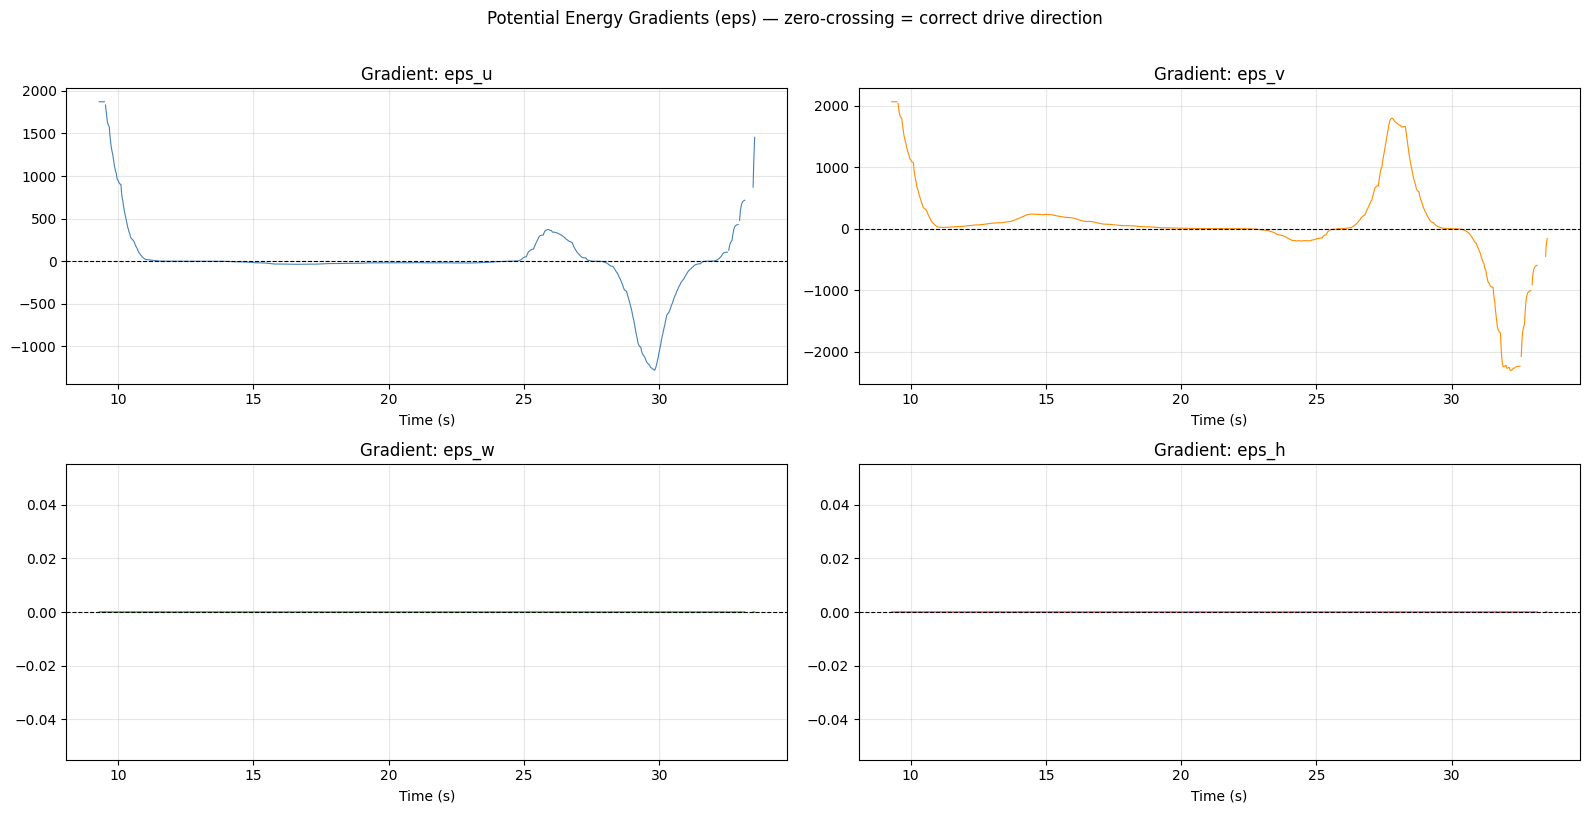

Gradient statistics (non-null rows):
            mean         std          min          max
eps_u   8.290257  397.658927 -1280.497207  1872.555051
eps_v  62.015535  672.225586 -2303.837279  2063.183843
eps_w   0.000000    0.000000    -0.000000    -0.000000
eps_h   0.000000    0.000000     0.000000     0.000000

Fraction of time each gradient is non-zero:
  eps_u: 71.6%
  eps_v: 74.8%
  eps_w: 0.0%
  eps_h: 0.0%


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

eps_cols = ['eps_u', 'eps_v', 'eps_w', 'eps_h']
colors   = ['steelblue', 'darkorange', 'green', 'crimson']

for ax, col, color in zip(axes.flat, eps_cols, colors):
    ax.plot(df['t_rel'], df[col], lw=0.8, color=color)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'Gradient: {col}')
    ax.set_xlabel('Time (s)')

plt.suptitle('Potential Energy Gradients (eps) — zero-crossing = correct drive direction', y=1.01)
plt.tight_layout()
plt.savefig('4_eps_gradients.png', dpi=150)
plt.show()

# Check sign consistency vs error
# eps_u should be negative when u_f > 0.5 (target right of centre) to push left
# Adjust 0.5 to your image centre normalisation
eps_data = df[eps_cols].dropna()
print("Gradient statistics (non-null rows):")
print(eps_data.describe().T[['mean','std','min','max']].to_string())

print("\nFraction of time each gradient is non-zero:")
for col in eps_cols:
    nz = (df[col].abs() > 1e-9).mean()
    print(f"  {col}: {100*nz:.1f}%")

## 5 · Depth Estimate `Z_est`
Is the thin-lens depth consistent with bounding box area trends?

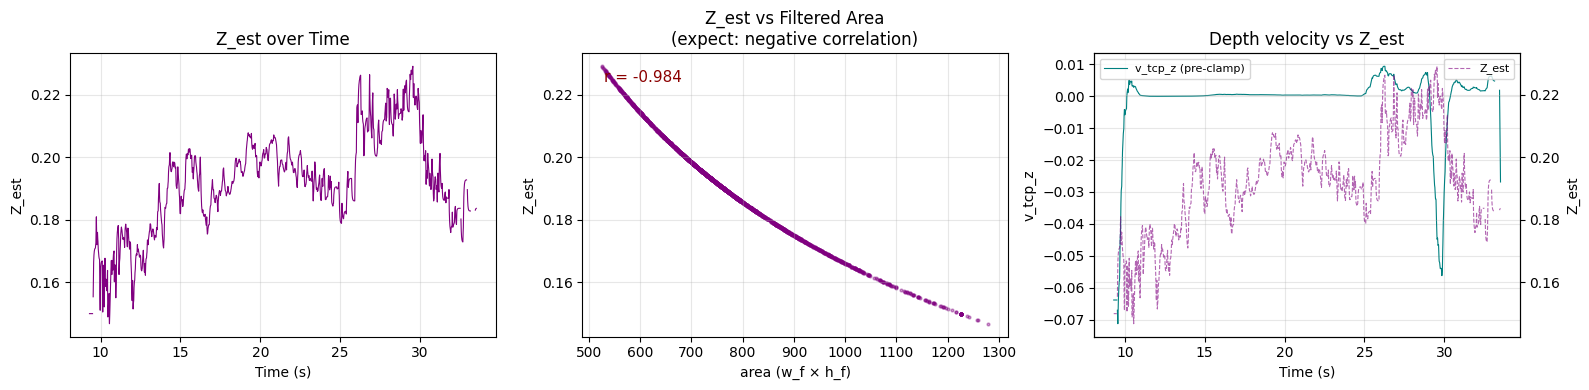

Z_est / area correlation: -0.9840
  ✓ Negative correlation as expected.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Z_est over time
axes[0].plot(df['t_rel'], df['Z_est'], lw=0.8, color='purple')
axes[0].set_title('Z_est over Time'); axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Z_est')

# Z_est vs filtered area (should be inversely correlated: larger bbox → smaller Z)
both = df[['Z_est', 'area']].dropna()
axes[1].scatter(both['area'], both['Z_est'], s=4, alpha=0.4, color='purple')
axes[1].set_title('Z_est vs Filtered Area\n(expect: negative correlation)')
axes[1].set_xlabel('area (w_f × h_f)'); axes[1].set_ylabel('Z_est')
if not both.empty:
    corr = both['Z_est'].corr(both['area'])
    axes[1].annotate(f'r = {corr:.3f}', xy=(0.05, 0.9), xycoords='axes fraction',
                     fontsize=11, color='darkred')

# v_tcp_z vs Z_est (is depth velocity proportional?)
axes[2].plot(df['t_rel'], df['v_tcp_z'], lw=0.8, label='v_tcp_z (pre-clamp)', color='teal')
ax2 = axes[2].twinx()
ax2.plot(df['t_rel'], df['Z_est'], lw=0.8, ls='--', label='Z_est', color='purple', alpha=0.6)
axes[2].set_title('Depth velocity vs Z_est'); axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('v_tcp_z'); ax2.set_ylabel('Z_est')
axes[2].legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('5_z_est.png', dpi=150)
plt.show()

if not both.empty:
    print(f"Z_est / area correlation: {corr:.4f}")
    if corr > 0:
        print("  ⚠️  Positive correlation — Z_est increases with area. Check thin-lens calibration or sign convention.")
    else:
        print("  ✓ Negative correlation as expected.")

## 6 · Saturation Diagnosis
Compare pre-clamp `v_tcp_*` against final `vx/vy/vz/wx/wy/wz` to detect persistent clipping.

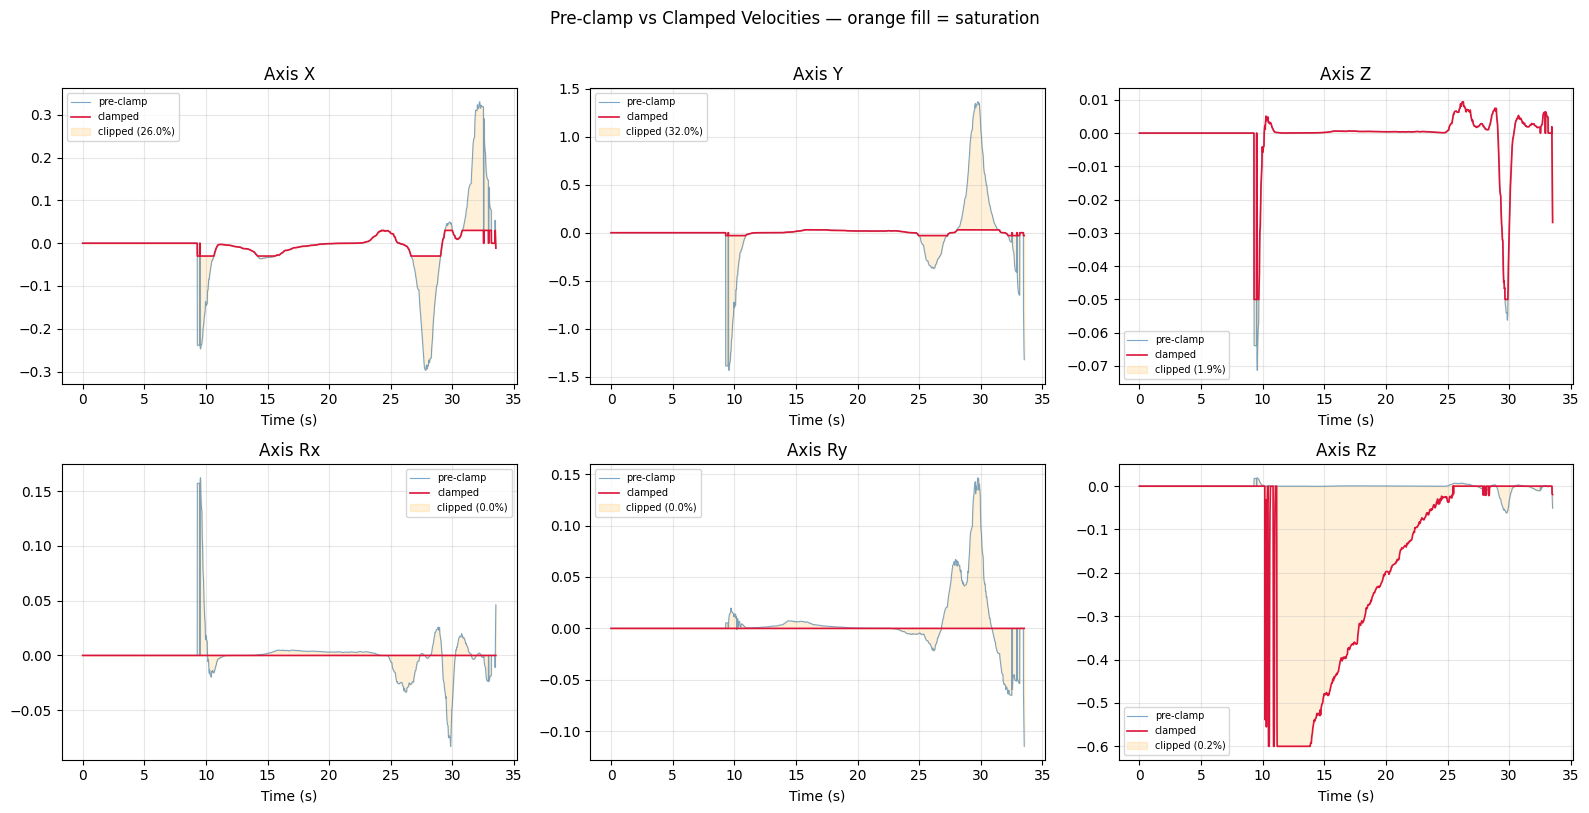

Saturation fractions:
  X: 26.0%  ⚠️  Persistent saturation!
  Y: 32.0%  ⚠️  Persistent saturation!
  Z: 1.9%  ✓
  Rx: 0.0%  ✓
  Ry: 0.0%  ✓
  Rz: 0.2%  ✓


In [28]:
axes_pairs = [
    ('v_tcp_x', 'vx', 'X'),
    ('v_tcp_y', 'vy', 'Y'),
    ('v_tcp_z', 'vz', 'Z'),
    ('v_tcp_wx', 'wx', 'Rx'),
    ('v_tcp_wy', 'wy', 'Ry'),
    ('v_tcp_wz', 'wz', 'Rz'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

clamp_report = {}

for ax, (pre, post, label) in zip(axes.flat, axes_pairs):
    pre_vals  = df[pre].fillna(0)
    post_vals = df[post].fillna(0)
    saturated = (pre_vals.abs() > post_vals.abs() + 1e-9) & (post_vals.abs() > 1e-9)
    sat_frac = saturated.mean()
    clamp_report[label] = sat_frac

    ax.plot(df['t_rel'], pre_vals,  lw=0.8, alpha=0.7, label='pre-clamp', color='steelblue')
    ax.plot(df['t_rel'], post_vals, lw=1.2, label='clamped',   color='crimson')
    ax.fill_between(df['t_rel'], pre_vals, post_vals, alpha=0.15, color='orange',
                    label=f'clipped ({100*sat_frac:.1f}%)')
    ax.set_title(f'Axis {label}'); ax.set_xlabel('Time (s)')
    ax.legend(fontsize=7)

plt.suptitle('Pre-clamp vs Clamped Velocities — orange fill = saturation', y=1.01)
plt.tight_layout()
plt.savefig('6_saturation.png', dpi=150)
plt.show()

print("Saturation fractions:")
for ax_name, frac in clamp_report.items():
    flag = '  ⚠️  Persistent saturation!' if frac > 0.1 else '  ✓'
    print(f"  {ax_name}: {100*frac:.1f}%{flag}")

## 7 · Orientation: `e_th`, deadband, and `wz`
Check angle filter integrity and that the deadband behaves correctly.

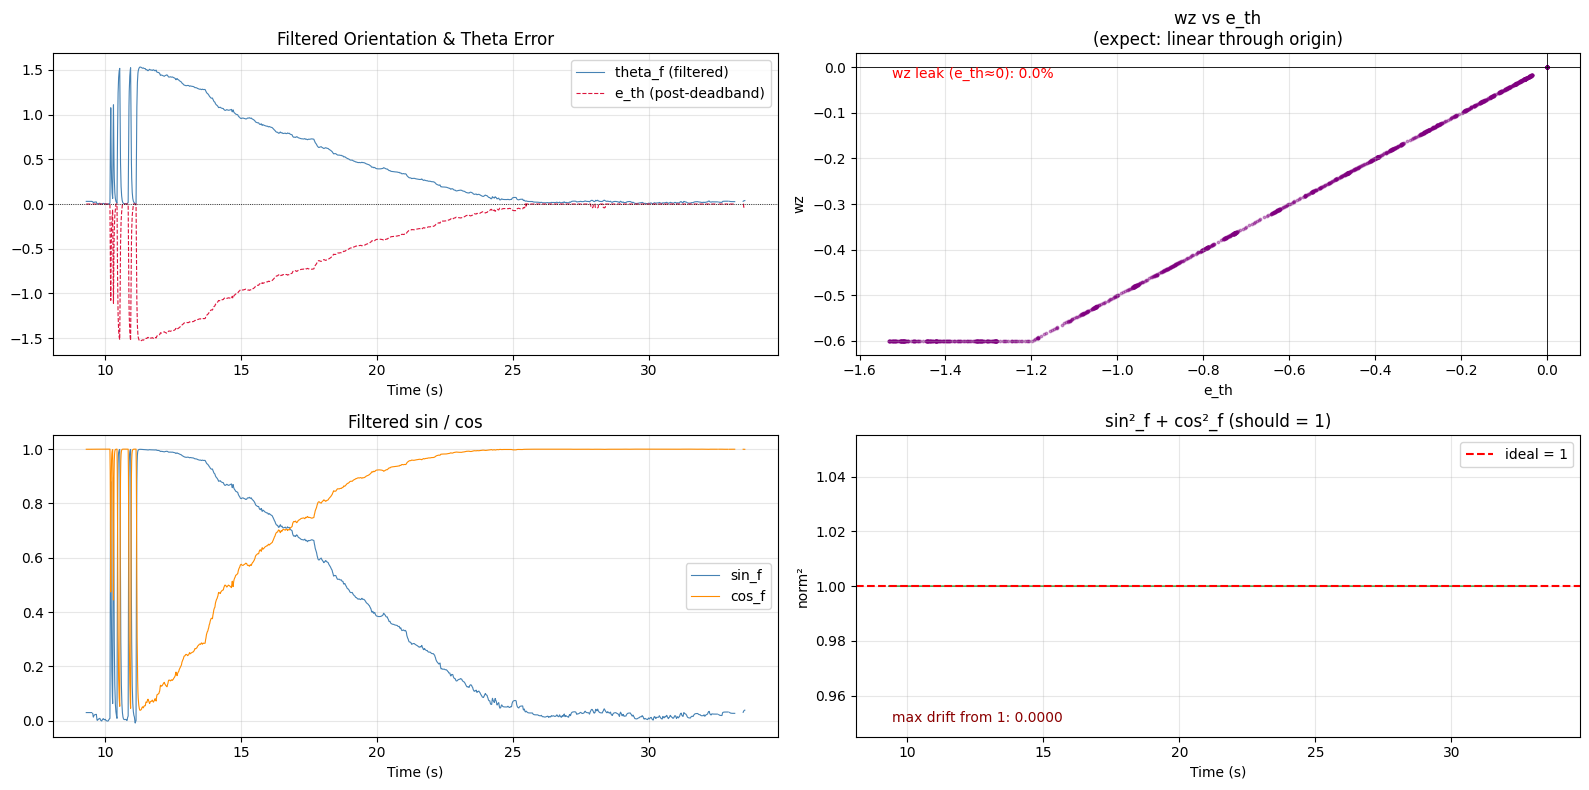

wz leak when e_th≈0: 0.00%
Max |sin²+cos²−1|:   0.000000


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# 7a: theta_f and e_th over time
axes[0,0].plot(df['t_rel'], df['theta_f'], lw=0.8, label='theta_f (filtered)', color='steelblue')
axes[0,0].plot(df['t_rel'], df['e_th'], lw=0.8, label='e_th (post-deadband)', color='crimson', ls='--')
axes[0,0].axhline(0, color='black', lw=0.6, ls=':')
axes[0,0].set_title('Filtered Orientation & Theta Error'); axes[0,0].set_xlabel('Time (s)')
axes[0,0].legend()

# 7b: wz vs e_th — should be proportional; wz non-zero only when e_th != 0
axes[0,1].scatter(df['e_th'], df['wz'], s=3, alpha=0.4, color='purple')
axes[0,1].axhline(0, color='black', lw=0.6); axes[0,1].axvline(0, color='black', lw=0.6)
axes[0,1].set_title('wz vs e_th\n(expect: linear through origin)')
axes[0,1].set_xlabel('e_th'); axes[0,1].set_ylabel('wz')

# Flag: wz non-zero when e_th is zero
leak = ((df['e_th'].abs() < 1e-9) & (df['wz'].abs() > 1e-6)).mean()
axes[0,1].annotate(f'wz leak (e_th≈0): {100*leak:.1f}%', xy=(0.05, 0.92),
                   xycoords='axes fraction', color='red', fontsize=10)

# 7c: sin_f and cos_f over time
axes[1,0].plot(df['t_rel'], df['sin_f'], lw=0.8, label='sin_f', color='steelblue')
axes[1,0].plot(df['t_rel'], df['cos_f'], lw=0.8, label='cos_f', color='darkorange')
axes[1,0].set_title('Filtered sin / cos'); axes[1,0].set_xlabel('Time (s)')
axes[1,0].legend()

# 7d: sin²+cos² should equal 1 — drift = filter corruption
norm_sq = df['sin_f']**2 + df['cos_f']**2
axes[1,1].plot(df['t_rel'], norm_sq, lw=0.8, color='green')
axes[1,1].axhline(1.0, color='red', ls='--', label='ideal = 1')
axes[1,1].set_title('sin²_f + cos²_f (should = 1)'); axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('norm²')
axes[1,1].legend()

max_drift = (norm_sq - 1).abs().max()
axes[1,1].annotate(f'max drift from 1: {max_drift:.4f}', xy=(0.05, 0.05),
                   xycoords='axes fraction', fontsize=10, color='darkred')

plt.tight_layout()
plt.savefig('7_orientation.png', dpi=150)
plt.show()

print(f"wz leak when e_th≈0: {100*leak:.2f}%")
print(f"Max |sin²+cos²−1|:   {max_drift:.6f}")
if max_drift > 0.05:
    print("  ⚠️  Orientation filter normalisation drifting — renormalise at each step.")

## 8 · Loop Timing
Is the control loop running at a consistent rate? Variable dt destabilises discrete-time controllers.

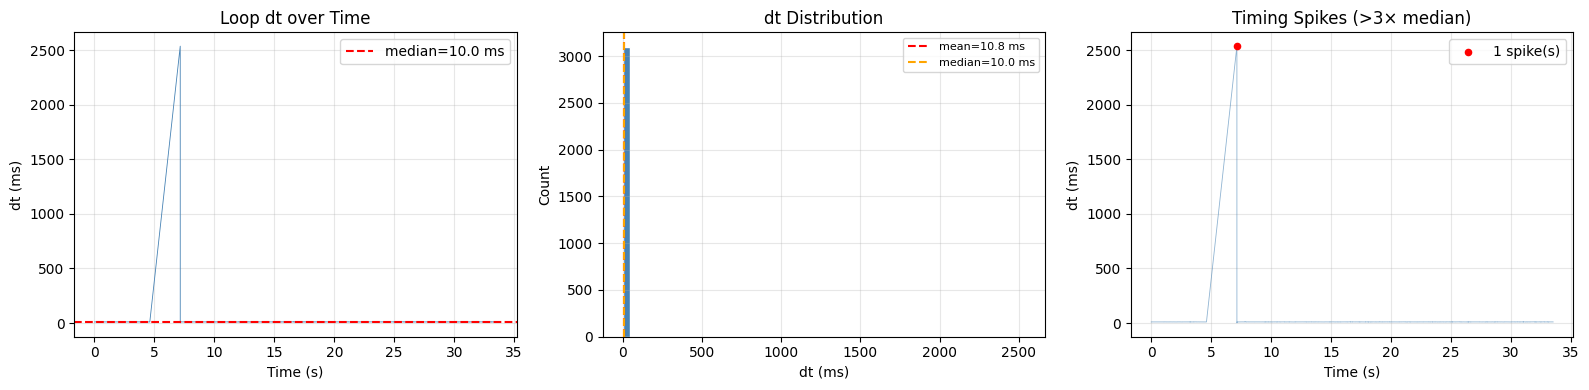

Loop rate  — mean: 92.5 Hz  |  median: 99.6 Hz
dt std:  45.41 ms  (CV = 4.199)
Max dt:  2538.29 ms
Spikes > 3×median: 1
  ⚠️  High timing jitter (CV > 0.2). Consider fixed-rate loop or dt-normalised gains.


In [30]:
dt = df['time'].diff().dropna() * 1000  # milliseconds

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# dt over time
axes[0].plot(df['t_rel'].iloc[1:], dt, lw=0.6, color='steelblue')
axes[0].axhline(dt.median(), color='red', ls='--', label=f'median={dt.median():.1f} ms')
axes[0].set_title('Loop dt over Time'); axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('dt (ms)')
axes[0].legend()

# dt histogram
axes[1].hist(dt, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(dt.mean(),   color='red',    ls='--', label=f'mean={dt.mean():.1f} ms')
axes[1].axvline(dt.median(), color='orange', ls='--', label=f'median={dt.median():.1f} ms')
axes[1].set_title('dt Distribution'); axes[1].set_xlabel('dt (ms)'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# Spike detection (dt > 3× median)
spikes = dt[dt > 3 * dt.median()]
axes[2].plot(df['t_rel'].iloc[1:], dt, lw=0.6, color='steelblue', alpha=0.6)
axes[2].scatter(df['t_rel'].iloc[1:].loc[spikes.index], spikes,
                color='red', s=20, zorder=5, label=f'{len(spikes)} spike(s)')
axes[2].set_title('Timing Spikes (>3× median)'); axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('dt (ms)')
axes[2].legend()

plt.tight_layout()
plt.savefig('8_timing.png', dpi=150)
plt.show()

print(f"Loop rate  — mean: {1000/dt.mean():.1f} Hz  |  median: {1000/dt.median():.1f} Hz")
print(f"dt std:  {dt.std():.2f} ms  (CV = {dt.std()/dt.mean():.3f})")
print(f"Max dt:  {dt.max():.2f} ms")
print(f"Spikes > 3×median: {len(spikes)}")
if dt.std() / dt.mean() > 0.2:
    print("  ⚠️  High timing jitter (CV > 0.2). Consider fixed-rate loop or dt-normalised gains.")

## 9 · Summary Dashboard
All output channels at a glance.

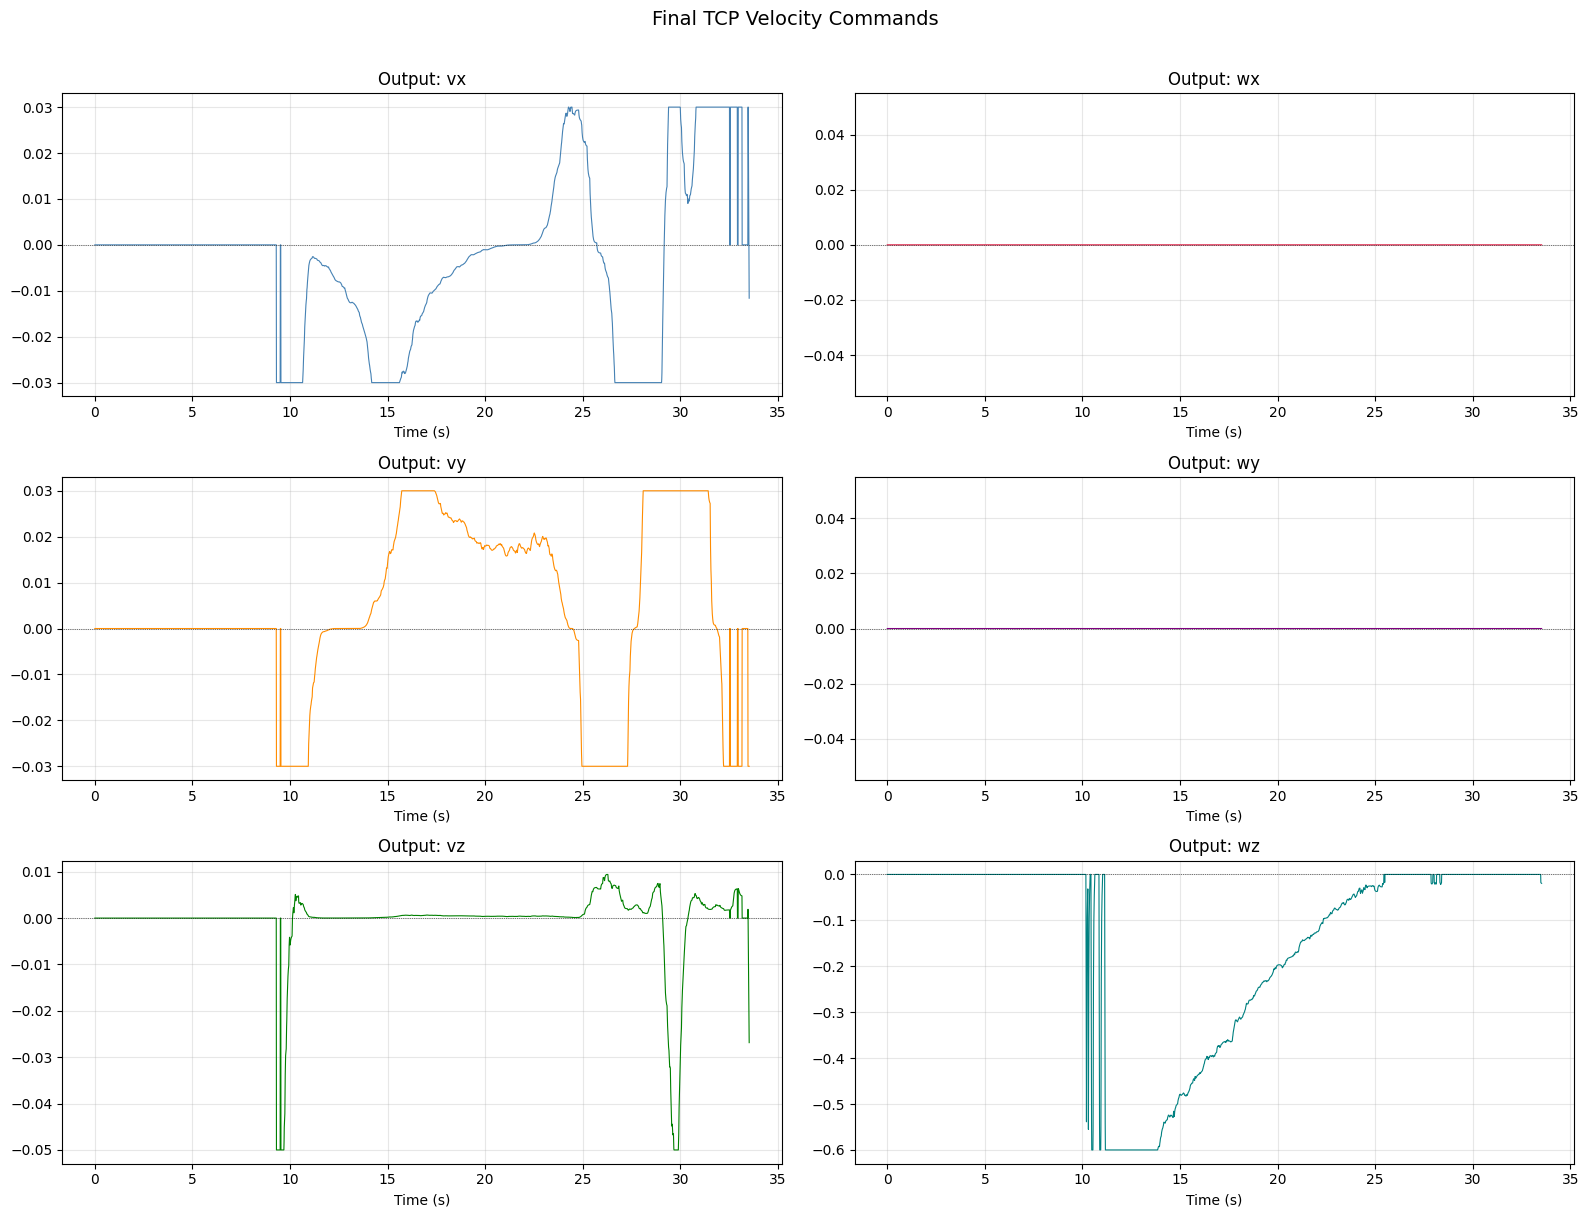

Fraction of time each output is non-zero:
  vx: 76.8%
  vy: 76.8%
  vz: 76.8%
  wx: 0.0%  ← robot stationary on this axis the whole time
  wy: 0.0%  ← robot stationary on this axis the whole time
  wz: 49.1%


In [31]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Translational
for ax, col, color in zip(axes[:,0], ['vx','vy','vz'], ['steelblue','darkorange','green']):
    ax.plot(df['t_rel'], df[col], lw=0.8, color=color)
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_title(f'Output: {col}'); ax.set_xlabel('Time (s)')

# Rotational
for ax, col, color in zip(axes[:,1], ['wx','wy','wz'], ['crimson','purple','teal']):
    ax.plot(df['t_rel'], df[col], lw=0.8, color=color)
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_title(f'Output: {col}'); ax.set_xlabel('Time (s)')

plt.suptitle('Final TCP Velocity Commands', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('9_output_summary.png', dpi=150)
plt.show()

# Zero-output audit — is the robot even moving?
print("Fraction of time each output is non-zero:")
for col in ['vx','vy','vz','wx','wy','wz']:
    nz = (df[col].abs() > 1e-9).mean()
    flag = '  ← robot stationary on this axis the whole time' if nz < 0.01 else ''
    print(f"  {col}: {100*nz:.1f}%{flag}")